# Regression Discontinuity Design

In [114]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import re
from rdd import rdd

sns.set_theme(style='whitegrid', context='notebook')


## data preparation

In [2]:

df = pd.read_parquet('cleaned_datasets/resale_with_all_features.parquet')
df.columns

Index(['month', 'year', 'town', 'flat_type', 'storey_range', 'floor_area_sqm',
       'flat_model', 'remaining_lease', 'geometry', 'postal_code',
       'resale_price', 'num_schools_1km', 'num_schools_2km',
       'num_tier1_schools_1km', 'num_tier1_schools_2km',
       'num_tier2_schools_1km', 'num_tier2_schools_2km',
       'nearest_tier1_primary_school_dist_m', 'num_unique_mrt_500m',
       'num_unique_mrt_1km', 'num_unique_mrt_lines_500m',
       'num_unique_mrt_lines_1km', 'walking_dist_mrt_m', 'num_busstops_500m',
       'num_busstops_1km', 'walking_dist_busstop_m', 'num_unique_hawker_500m',
       'num_unique_hawker_1km', 'walking_dist_hawker_m', 'num_malls_1km',
       'num_malls_2km', 'walking_dist_mall_m', 'dist_cbd_m'],
      dtype='object')

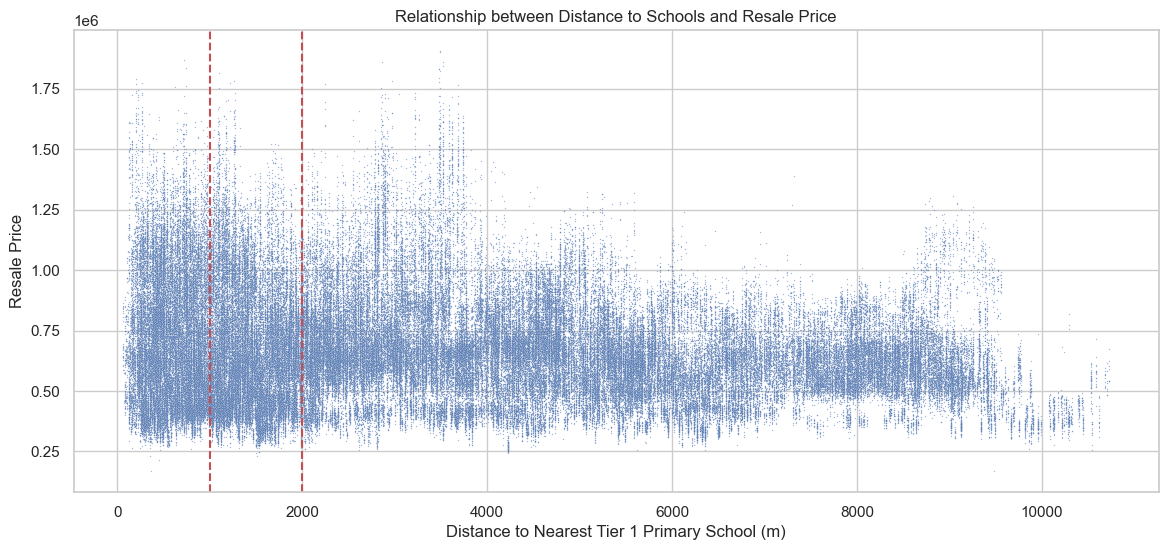

In [3]:
plt.figure(figsize=(14, 6))
sns.scatterplot(data=df, x='nearest_tier1_primary_school_dist_m', y='resale_price', alpha=0.5, s=1)
plt.axvline(x=1000, color='r', linestyle='--', label='1 km')
plt.axvline(x=2000, color='r', linestyle='--', label='2 km')
plt.xlabel('Distance to Nearest Tier 1 Primary School (m)')
plt.ylabel('Resale Price')
plt.title('Relationship between Distance to Schools and Resale Price')
plt.show()


In [4]:
df_schooltier = pd.read_csv('cleaned_datasets/schools_tiered.csv')
sch_locations = pd.read_csv('data_cleaning_school/General information of schools.csv')
tier1_schools = df_schooltier[df_schooltier['school_tier'] == 'Tier 1']['school_name']
sch_locations_tier1 = sch_locations[sch_locations['school_name'].isin(tier1_schools)]
sch_locations_tier1


,school_name,url_address,address,postal_code,telephone_no,telephone_no_2,fax_no,fax_no_2,email_address,mrt_desc,...,nature_code,session_code,mainlevel_code,sap_ind,autonomous_ind,gifted_ind,ip_ind,mothertongue1_code,mothertongue2_code,mothertongue3_code
4,AI TONG SCHOOL,http://www.aitong.moe.edu.sg,100 Bright Hill Drive,579646,64547672,na,64532726,na,AITONG_SCH@MOE.EDU.SG,Bishan MRT,...,CO-ED SCHOOL,SINGLE SESSION,PRIMARY,Yes,No,No,No,CHINESE,na,na
16,ANGLO-CHINESE SCHOOL (JUNIOR),www.acsj.moe.edu.sg,16 WINSTEDT ROAD,227988,67337911,67337912,67346518,na,ACJS@MOE.EDU.SG,Newton MRT Station,...,BOYS' SCHOOL,SINGLE SESSION,PRIMARY,No,No,No,No,CHINESE,MALAY,TAMIL
17,ANGLO-CHINESE SCHOOL (PRIMARY),http://www.acspri.moe.edu.sg/,50 BARKER ROAD,309918,62501633,na,63531366,na,ACPS@MOE.EDU.SG,Newton MRT Station,...,BOYS' SCHOOL,SINGLE SESSION,PRIMARY,No,No,Yes,No,CHINESE,MALAY,TAMIL
47,CATHOLIC HIGH SCHOOL,http://www.catholichigh.moe.edu.sg,9 BISHAN STREET 22,579767,64582177 (Secondary),64589869 (Primary),64561322 (Secondary),64593938 (Primary),CHS@MOE.EDU.SG,BISHAN MRT,...,BOYS' SCHOOL,SINGLE SESSION,MIXED LEVEL (P1-S4),Yes,Yes,Yes,Yes,CHINESE,na,na
63,CHIJ ST. NICHOLAS GIRLS' SCHOOL,http://www.chijstnicholasgirls.moe.edu.sg,501 ANG MO KIO STREET 13,569405,63541839 (Secondary),64549698 (Primary),64511335 (Secondary),64566169 (Primary),CHIJSNG@MOE.EDU.SG,"ANG MO KIO MRT, YIO CHU KANG MRT, MAYFLOWER MRT",...,GIRLS' SCHOOL,SINGLE SESSION,MIXED LEVEL (P1-S4),Yes,Yes,No,Yes,CHINESE,na,na
122,HENRY PARK PRIMARY SCHOOL,http://www.henryparkpri.moe.edu.sg,1 HOLLAND GROVE ROAD,278790,64663600,na,64691840,na,HPPS@MOE.EDU.SG,"Buona Vista MRT, Clementi MRT",...,CO-ED SCHOOL,SINGLE SESSION,PRIMARY,No,No,Yes,No,CHINESE,MALAY,TAMIL
125,HOLY INNOCENTS' PRIMARY SCHOOL,http://www.holyinnocentspri.moe.edu.sg/,5 Lorong Low Koon,536451,62886516,na,62876393,na,HOLYINNOCENT@MOE.EDU.SG,2km walk to Hougang MRT,...,CO-ED SCHOOL,SINGLE SESSION,PRIMARY,Yes,No,No,No,CHINESE,na,na
126,HONG WEN SCHOOL,http://www.hongwen.moe.edu.sg,30 TOWNER ROAD,327829,62943340,na,62937625,na,HWS@MOE.EDU.SG,Boon Keng MRT,...,CO-ED SCHOOL,SINGLE SESSION,PRIMARY,Yes,No,No,No,CHINESE,na,na
149,KONG HWA SCHOOL,http://www.konghwa.moe.edu.sg,350 GUILLEMARD ROAD,399772,63421195,na,63421120,na,KONGHWA_SCH@MOE.EDU.SG,Dakota,...,CO-ED SCHOOL,SINGLE SESSION,PRIMARY,Yes,No,No,No,CHINESE,na,na
157,MAHA BODHI SCHOOL,http://www.mahabodhi.moe.edu.sg/,10 UBI AVENUE 1,408931,67442115,na,67443752,na,MBS@MOE.EDU.SG,"Eunos Station (Transfer Bus No.63, 63M); Ubi S...",...,CO-ED SCHOOL,SINGLE SESSION,PRIMARY,Yes,No,No,No,CHINESE,na,na


In [5]:

df_full = pd.read_parquet('cleaned_datasets/resale_with_all_features_dummies.parquet')
print(df_full.columns)

Index(['month', 'year', 'floor_area_sqm', 'remaining_lease', 'geometry',
       'postal_code', 'resale_price', 'num_schools_1km', 'num_schools_2km',
       'num_tier1_schools_1km', 'num_tier1_schools_2km',
       'num_tier2_schools_1km', 'num_tier2_schools_2km',
       'nearest_tier1_primary_school_dist_m', 'num_unique_mrt_500m',
       'num_unique_mrt_1km', 'num_unique_mrt_lines_500m',
       'num_unique_mrt_lines_1km', 'walking_dist_mrt_m', 'num_busstops_500m',
       'num_busstops_1km', 'walking_dist_busstop_m', 'num_unique_hawker_500m',
       'num_unique_hawker_1km', 'walking_dist_hawker_m', 'num_malls_1km',
       'num_malls_2km', 'walking_dist_mall_m', 'dist_cbd_m', 'town_BEDOK',
       'town_BISHAN', 'town_BUKIT BATOK', 'town_BUKIT MERAH',
       'town_BUKIT PANJANG', 'town_BUKIT TIMAH', 'town_CENTRAL AREA',
       'town_CHOA CHU KANG', 'town_CLEMENTI', 'town_GEYLANG', 'town_HOUGANG',
       'town_JURONG EAST', 'town_JURONG WEST', 'town_KALLANG/WHAMPOA',
       'town_MARINE PAR

In [6]:
# transform some variables for regression
df["log_price"] = np.log(df["resale_price"])
df["resale_price_psm"] = df["resale_price"] / df["floor_area_sqm"]

In [7]:
manual_drop_cols = ['month', 'year', 'geometry', 'postal_code',
    "num_schools_2km",              # collinear with num_schools_1km
    "num_tier2_schools_1km",        # collinear with num_tier1_schools_1km
    "num_tier2_schools_2km",        # same
    "num_unique_mrt_500m",          # collinear with walking_dist_mrt
    "num_unique_mrt_1km",           
    "num_unique_mrt_lines_500m",    
    "num_unique_mrt_lines_1km",
    "num_busstops_500m",            # collinear with walking_dist_busstop
    "num_busstops_1km",             
    "num_malls_1km",                # collinear with walking_dist_malls
    "num_malls_2km",
    "num_unique_hawker_500m",       # collinear with walking_dist_hawker
    "num_unique_hawker_1km"]
df_rdd = df.drop(columns=manual_drop_cols)
df_rdd.columns

Index(['town', 'flat_type', 'storey_range', 'floor_area_sqm', 'flat_model',
       'remaining_lease', 'resale_price', 'num_schools_1km',
       'num_tier1_schools_1km', 'num_tier1_schools_2km',
       'nearest_tier1_primary_school_dist_m', 'walking_dist_mrt_m',
       'walking_dist_busstop_m', 'walking_dist_hawker_m',
       'walking_dist_mall_m', 'dist_cbd_m', 'log_price', 'resale_price_psm'],
      dtype='object')

In [8]:
def convert_to_years(duration_str):
    if not isinstance(duration_str, str): return 0
    
    # Extract years and months using regex
    years = re.search(r'(\d+)\s*year', duration_str)
    months = re.search(r'(\d+)\s*month', duration_str)
    
    y = int(years.group(1)) if years else 0
    m = int(months.group(1)) if months else 0
    
    # Return total in months (continuous)
    return y * 12 + m
df_rdd['remaining_lease'] = df_rdd['remaining_lease'].apply(convert_to_years)
df_rdd

,town,flat_type,storey_range,floor_area_sqm,flat_model,remaining_lease,resale_price,num_schools_1km,num_tier1_schools_1km,num_tier1_schools_2km,nearest_tier1_primary_school_dist_m,walking_dist_mrt_m,walking_dist_busstop_m,walking_dist_hawker_m,walking_dist_mall_m,dist_cbd_m,log_price,resale_price_psm
0,ANG MO KIO,3 ROOM,01 TO 03,67.0,New Generation,696,356061.07,3,2,3,800.095964,609,442.0,276.0,1424,9283.1,12.782858,5314.344328
1,ANG MO KIO,3 ROOM,01 TO 03,60.0,Improved,792,363801.53,3,1,2,427.710939,348,257.0,331.0,1461,10143.1,12.804364,6063.358833
2,ANG MO KIO,3 ROOM,04 TO 06,67.0,New Generation,708,368445.80,3,0,1,1742.344901,789,245.0,449.0,1059,9065.4,12.817049,5499.191045
3,ANG MO KIO,3 ROOM,10 TO 12,61.0,Improved,793,371541.98,3,1,2,427.710939,348,257.0,331.0,1461,10143.1,12.825417,6090.852131
4,ANG MO KIO,3 ROOM,01 TO 03,68.0,New Generation,728,371541.98,2,0,1,1176.164205,526,210.0,331.0,1281,10643.7,12.825417,5463.852647
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
179998,YISHUN,EXECUTIVE,10 TO 12,145.0,Maisonette,735,975670.10,3,0,0,4472.022803,594,189.0,2086.0,1385,14417.5,13.790880,6728.759310
179999,YISHUN,EXECUTIVE,04 TO 06,146.0,Maisonette,736,985625.92,2,0,0,4598.089256,355,314.0,2131.0,1424,14564.9,13.801032,6750.862466
180000,YISHUN,EXECUTIVE,07 TO 09,142.0,Apartment,736,986110.02,2,0,0,4598.089256,355,314.0,2131.0,1424,14564.9,13.801523,6944.436761
180001,YISHUN,MULTI-GENERATION,04 TO 06,147.0,Multi Generation,738,944534.25,2,0,0,5013.125336,775,139.0,1316.0,610,14886.1,13.758447,6425.403061


In [9]:
cat_cols = ["flat_type", "flat_model", "storey_range", "town"]

for col in cat_cols:
    levels = sorted(df_rdd[col].dropna().unique())
    df_rdd[col] = pd.Categorical(df_rdd[col], categories=levels)

## Sharp RD

In [21]:
(np.array([0, 1000, 4000]) <= 1000).astype(int)

array([1, 1, 0])

In [17]:
def cv_mse(formula, df, kf, bandwidths, cutoff):
    results = []
    for bw in bandwidths:
        # determine the running and treatment variables based on cutoff
        df["running"] = df["nearest_tier1_primary_school_dist_m"] - cutoff 
        df["treated"] = (df["nearest_tier1_primary_school_dist_m"] <= cutoff).astype(int)
        df["treated_running"] = df["treated"] * df["running"] #interaction variable 

        # restrict to local window around cutoff
        df_bw = df[df["running"].between(-bw, bw)].copy()
    
        # skip if too few observations
        if len(df_bw) < 200:
            continue
    
        fold_mse = []
    
        for train_idx, test_idx in kf.split(df_bw):
            train_df = df_bw.iloc[train_idx].copy()
            test_df = df_bw.iloc[test_idx].copy()
        
            model = smf.ols(formula, data=train_df).fit(cov_type="HC1")
            preds = model.predict(test_df)
            mse = mean_squared_error(test_df["log_price"], preds)
            fold_mse.append(mse)

        model_all = smf.ols(formula, data=df_bw).fit(cov_type="HC1")
    
        results.append({
            "bandwidth": bw,
            "n_obs": len(df_bw),
            "cv_mse_mean": np.mean(fold_mse),
            "cv_mse_std": np.std(fold_mse),
            "treatment": model_all.params["treated"],
            "p-value": model_all.pvalues["treated"],
            "sig": '***' if model_all.pvalues["treated"] < 0.05 else ''
        })

    cv_results = pd.DataFrame(results).sort_values("cv_mse_mean")
    return(cv_results)


In [72]:
# finding optimal bandwidth h using CV
bandwidths = [50, 100, 150, 200, 250, 300, 350, 400, 450, 500]
kf = KFold(n_splits=5, shuffle=True, random_state=11)
f1 =  """
        log_price ~ treated + running + treated_running
        """
f2 = """
        log_price ~ treated + running + treated_running
          + floor_area_sqm
          + remaining_lease
          + C(town)
          + C(flat_type)
          + C(flat_model)
          + C(storey_range)
          + num_schools_1km
          + num_tier1_schools_1km
          + num_tier1_schools_2km
          + walking_dist_mrt_m
          + walking_dist_busstop_m
          + walking_dist_hawker_m
          + walking_dist_mall_m
          + dist_cbd_m
        """

In [73]:
print("Results for cutoff at 1 km:")
print("no controls:")
print(cv_mse(f1, df_rdd, kf, bandwidths, 1000))
print("")
print("with controls:")
print(cv_mse(f2, df_rdd, kf, bandwidths, 1000))
print("")

print("Results for cutoff at 2 km:")
print("no controls:")
print(cv_mse(f1, df_rdd, kf, bandwidths, 2000))
print("")
print("with controls:")
print(cv_mse(f2, df_rdd, kf, bandwidths, 2000))

Results for cutoff at 1 km:
no controls:
   bandwidth  n_obs  cv_mse_mean  cv_mse_std  treatment       p-value  sig
9        500  38569     0.130127    0.000645   0.034652  3.518931e-06  ***
8        450  34831     0.130586    0.000759   0.032431  4.072186e-05  ***
0         50   3429     0.130850    0.004616   0.102350  7.780535e-06  ***
7        400  31161     0.131836    0.001525   0.021705  9.952236e-03  ***
2        150  11468     0.132877    0.001024   0.101723  1.994569e-13  ***
4        250  19959     0.133118    0.001102   0.049785  3.104950e-06  ***
6        350  27395     0.133518    0.001233   0.002905  7.490829e-01     
5        300  24069     0.135202    0.001954   0.006980  4.772946e-01     
3        200  15678     0.136004    0.000864   0.102651  4.626743e-17  ***
1        100   7094     0.136803    0.002525   0.136166  8.174676e-16  ***

with controls:
   bandwidth  n_obs  cv_mse_mean  cv_mse_std  treatment       p-value  sig
0         50   3429     0.005970    0.00053

In [ ]:
# take the one with controls since we know the housing market is complex and is affected by many variables. (f2)
# Optimal bandwidth for 1km: 50m, treatment effect: 0.123892***
# means houses inside 1km is 12.39% more ex compared to houses outside
# Optimal bandwidth for 2km: 50m, treatment effect: 0.034949***
# means houses inside 2km is 3.49% more ex compared to houses outside

optimal_bandwidth = 50
# Cross-validation suggests that a 50m local window provides the best out-of-sample fit among the candidate bandwidths considered. 
# The main results are also checked for robustness across alternative bandwidths.

In [75]:
def plot_discontinuity(band, cutoff):
    df_plot = df_rdd[df_rdd["nearest_tier1_primary_school_dist_m"].between(cutoff-band,cutoff+band)].copy()

    # running variable
    df_plot["running"] = df_plot["nearest_tier1_primary_school_dist_m"] - cutoff

    # fitted values
    model = smf.ols(f2, data=df_rdd[df_rdd["nearest_tier1_primary_school_dist_m"].between(cutoff-band,cutoff+band)]).fit()
    df_plot["fitted"] = model.predict(df_plot)

    # split groups
    left = df_plot[df_plot["running"] < 0].sort_values("running")
    right = df_plot[df_plot["running"] >= 0].sort_values("running")

    plt.figure(figsize=(8,6))

    # scatter actual data
    plt.scatter(df_plot["running"], df_plot["log_price"], alpha=0.3)

    # fitted lines
    plt.plot(left["running"], left["fitted"], color="blue")
    plt.plot(right["running"], right["fitted"], color="red")

    plt.axvline(0, linestyle="--", color="black")

    plt.xlabel(f"Distance from {cutoff/1000}km cutoff")
    plt.ylabel("Log resale price")
    plt.title("RDD Plot")
    plt.show()

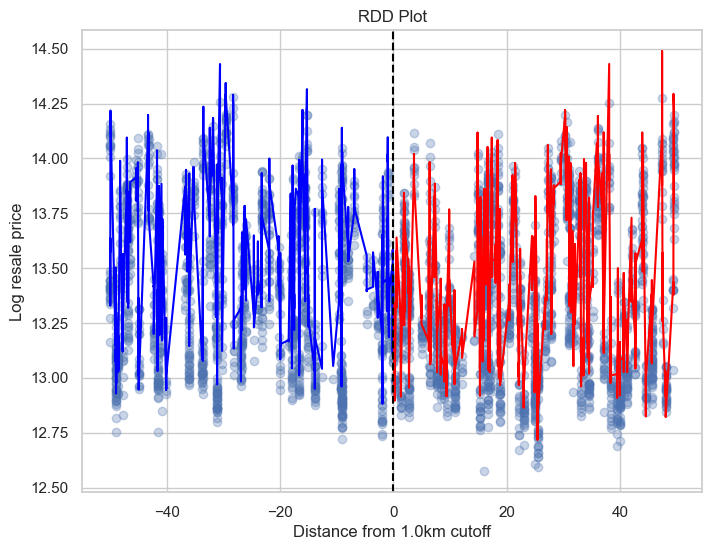

In [76]:
plot_discontinuity(50, 1000)

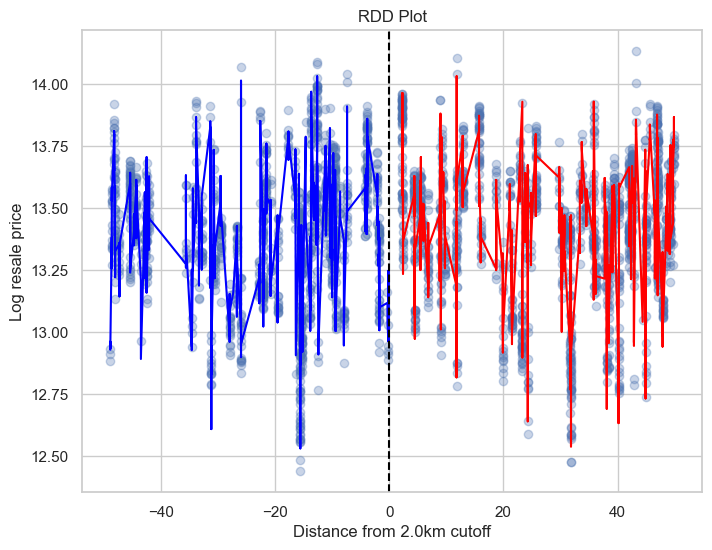

In [78]:
plot_discontinuity(50, 2000)

In [ ]:
# try out this formula for 
f3 = "log_price ~ treated + running + treated_running + C(town) + C(flat_type) + C(flat_model) + C(storey_range)"

print("no controls:")
print(cv_mse(f3, df_rdd, kf, bandwidths, 1000))
print("")
print("with controls:")
print(cv_mse(f3, df_rdd, kf, bandwidths, 2000))

no controls:
   bandwidth  n_obs  cv_mse_mean  cv_mse_std  treatment       p-value  sig
0         50   3429     0.013131    0.000542   0.069275  4.956658e-16  ***
2        150  11468     0.013218    0.000393   0.028743  1.340423e-09  ***
1        100   7094     0.013595    0.000627   0.029699  4.928959e-07  ***
3        200  15678     0.013931    0.000375   0.019313  2.540044e-06  ***
4        250  19959     0.014369    0.000338   0.009789  6.883152e-03  ***
6        350  27395     0.014866    0.000358   0.008802  3.743486e-03  ***
5        300  24069     0.014950    0.000270  -0.000780  8.142506e-01     
7        400  31161     0.015334    0.000295   0.016100  1.734513e-08  ***
8        450  34831     0.015442    0.000180   0.017183  1.255169e-10  ***
9        500  38569     0.015630    0.000451   0.008506  7.927880e-04  ***

with controls:
   bandwidth  n_obs  cv_mse_mean  cv_mse_std  treatment       p-value  sig
0         50   2624     0.010315    0.001062   0.009923  2.615653e-01  

## Testing Validity of RD

### Test 1: Balance Test

In [ ]:
# testing other covariates are balanced at the cutoff
balance_vars = [
    "floor_area_sqm",
    "remaining_lease",
    "num_schools_1km",
    "num_tier1_schools_1km", 
    "num_tier1_schools_2km", 
    "walking_dist_mrt_m",
    "walking_dist_busstop_m",
    "walking_dist_hawker_m",
    "walking_dist_mall_m",
    "dist_cbd_m"
]

def balance_test(balance_vars, cutoff, band): 
    res = []
    for var in balance_vars:
        balance_vars_clean = [v for v in balance_vars if v != var]
        bal_formula = f"{var} ~ treated + running + treated_running + C(town) + C(flat_type) + C(flat_model) + C(storey_range) + \
            + {' + '.join(balance_vars_clean)}"
        bal_model = smf.ols(bal_formula, data=df_rdd[df_rdd["nearest_tier1_primary_school_dist_m"].between(cutoff-band,cutoff+band)]).fit(cov_type='HC1')
        res.append({
            "variable": var,
            "treatment": bal_model.params.get("treated"),
            "p-value": bal_model.pvalues.get("treated"),
            "sig": '***' if bal_model.pvalues.get("treated") < 0.05 else ''
        })
    return pd.DataFrame(res)

In [ ]:
balance_test(balance_vars, 1000, 50)
# significant also so how. also tried without the other balance var btw also significant 

,variable,treatment,p-value,sig
0,floor_area_sqm,45.731096,1.056882e-44,***
1,remaining_lease,966.360032,2.445510e-71,***
2,num_schools_1km,-0.670265,2.182202e-01,
3,num_tier1_schools_1km,-8.067839,0.000000e+00,***
4,num_tier1_schools_2km,0.847514,1.369065e-02,***
5,walking_dist_mrt_m,-578.796493,2.032058e-03,***
6,walking_dist_busstop_m,-82.877253,2.513689e-01,
7,walking_dist_hawker_m,-761.206582,9.667870e-05,***
8,walking_dist_mall_m,1578.306795,6.757644e-06,***
9,dist_cbd_m,4663.510948,1.343945e-37,***


In [109]:
balance_test(balance_vars, 2000, 50)

,variable,treatment,p-value,sig
0,floor_area_sqm,53.285219,1.820326e-60,***
1,remaining_lease,1315.073127,5.721278e-78,***
2,num_schools_1km,10.183853,8.577549e-61,***
3,num_tier1_schools_1km,0.000000,NaN,
4,num_tier1_schools_2km,-3.435219,3.827597e-61,***
5,walking_dist_mrt_m,3436.206171,1.586956e-209,***
6,walking_dist_busstop_m,483.378991,1.452642e-08,***
7,walking_dist_hawker_m,-2585.639482,3.860603e-20,***
8,walking_dist_mall_m,-2426.825466,1.424640e-105,***
9,dist_cbd_m,4567.244458,0.000000e+00,***


### Test 2: Density Test

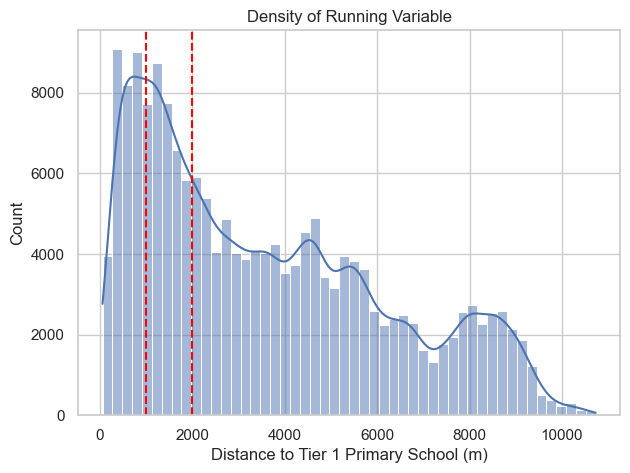

In [ ]:
# testing for discontinuity in the density of the running variable at the cutoff
running = df_rdd["nearest_tier1_primary_school_dist_m"]

plt.figure(figsize=(7,5))
sns.histplot(running, bins=50, kde=True)
plt.axvline(1000, linestyle="--", color="red")
plt.axvline(2000, linestyle="--", color="red")
plt.xlabel("Distance to Tier 1 Primary School (m)")
plt.title("Density of Running Variable")
plt.show()

In [ ]:
df_rdd[df_rdd["nearest_tier1_primary_school_dist_m"].between(900,1000)]

<bound method Series.count of 7         986.139699
16        986.139699
25        951.115289
48        924.900766
91        930.619293
             ...    
176299    905.964846
176300    905.964846
176457    956.851567
176546    904.770468
176547    915.660547
Name: nearest_tier1_primary_school_dist_m, Length: 3119, dtype: float64>

In [125]:
def plot_density(bandwidth, cutoff):

    df_bw = df_rdd[
        df_rdd["nearest_tier1_primary_school_dist_m"].between(cutoff - bandwidth, cutoff + bandwidth)
    ].copy()

    df_bw["running"] = df_bw["nearest_tier1_primary_school_dist_m"] - cutoff

    plt.figure(figsize=(7,5))

    sns.histplot(
        df_bw["running"],
        bins=40,
        stat="density",
        edgecolor="black"
    )

    plt.axvline(0, linestyle="--", color="red")
    plt.xlabel("Distance from cutoff (meters)")
    plt.ylabel("Density")
    plt.title("Density of Running Variable Around 1km Cutoff")

    plt.show()

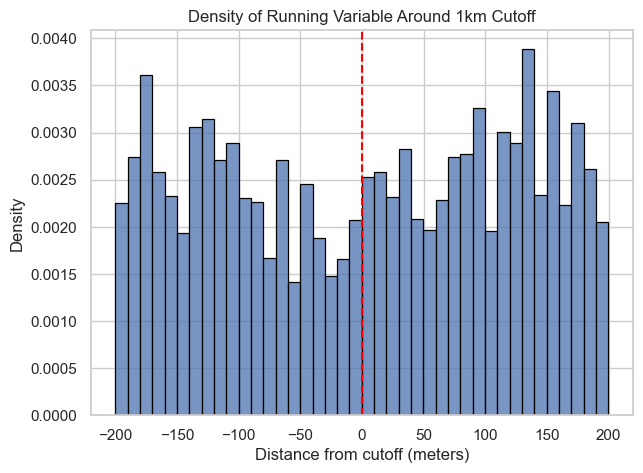

In [130]:
plot_density(200, 1000)

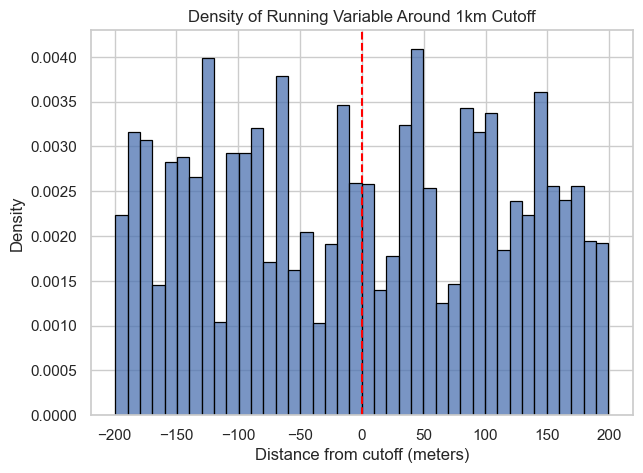

In [ ]:
plot_density(200, 2000)
# fairly same density, should be fine 

### Test 3: Placebo Cutoffs

In [ ]:
# try different placebo cutoffs to check if they are insignificant
placebo_cutoffs = [500, 800, 1200, 1500, 1800, 2200, 2500]
for cutoffs in placebo_cutoffs:
    print(f"test for {cutoffs}m cutoff")
    print(cv_mse(f2, df_rdd, kf, [50], cutoffs))
    print('')

# cooked. significant so how 

test for 500m cutoff
   bandwidth  n_obs  cv_mse_mean  cv_mse_std  treatment   p-value sig
0         50   4555     0.004777    0.000229   0.000845  0.837173    

test for 800m cutoff
   bandwidth  n_obs  cv_mse_mean  cv_mse_std  treatment   p-value  sig
0         50   4274     0.005294    0.000519  -0.011612  0.018903  ***

test for 1200m cutoff
   bandwidth  n_obs  cv_mse_mean  cv_mse_std  treatment   p-value  sig
0         50   4217     0.005425    0.000346   0.019482  0.000191  ***

test for 1500m cutoff
   bandwidth  n_obs  cv_mse_mean  cv_mse_std  treatment   p-value  sig
0         50   3543     0.005336    0.000675   0.016908  0.001456  ***

test for 1800m cutoff
   bandwidth  n_obs  cv_mse_mean  cv_mse_std  treatment   p-value sig
0         50   2852     0.006024      0.0005    0.01262  0.059305    

test for 2200m cutoff
   bandwidth  n_obs  cv_mse_mean  cv_mse_std  treatment   p-value  sig
0         50   2375     0.003206    0.000163   0.010736  0.045282  ***

test for 2500m c